# Applying KNN Classifier on Breast Cancer Dataset

### Loading dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("E:/Dataset/breast_cancer.csv")

In [3]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
116,864726,B,8.950,15.76,58.74,245.2,0.09462,0.12430,0.09263,0.02308,...,9.414,17.07,63.34,270.0,0.1179,0.18790,0.15440,0.03846,0.1652,0.07722
130,866714,B,12.190,13.29,79.08,455.8,0.10660,0.09509,0.02855,0.02882,...,13.340,17.81,91.38,545.2,0.1427,0.25850,0.09915,0.08187,0.3469,0.09241
68,859471,B,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,...,10.310,22.65,65.50,324.7,0.1482,0.43650,1.25200,0.17500,0.4228,0.11750
503,915143,M,23.090,19.83,152.10,1682.0,0.09342,0.12750,0.16760,0.10030,...,30.790,23.87,211.50,2782.0,0.1199,0.36250,0.37940,0.22640,0.2908,0.07277
140,868999,B,9.738,11.97,61.24,288.5,0.09250,0.04102,0.00000,0.00000,...,10.620,14.10,66.53,342.9,0.1234,0.07204,0.00000,0.00000,0.3105,0.08151


### Analyzing dataset

In [4]:
df.shape

(569, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df = df.drop(columns=["id"])

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Splitting dataset into train, and test set

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=19)

In [11]:
x_train.shape

(455, 30)

### Scaling our data into the same scale

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

In [14]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
x_train_scaled

array([[-0.50156087,  1.73830078, -0.44113971, ...,  0.44872926,
         0.46225254,  1.94454335],
       [ 3.77995511,  1.60294549,  3.91297177, ...,  2.20185791,
        -0.44695576, -0.56536913],
       [-0.46749045, -1.48040218, -0.53666254, ..., -1.34198791,
        -1.01877491, -0.78199364],
       ...,
       [-0.17221349, -1.50793207, -0.25421143, ..., -1.41265433,
        -1.03936674, -1.23587355],
       [-0.16085668, -1.12939609, -0.1813341 , ...,  0.19162377,
         0.08526373, -0.65657945],
       [-0.84226506, -1.19592666, -0.8491704 , ..., -1.15524813,
        -0.54991489, -0.78742282]], shape=(455, 30))

### Training our KNN Classifier model

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

In [18]:
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Testing the performance of our model

In [19]:
y_pred = knn.predict(x_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score, recall_score

In [21]:
print(f"Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9385964912280702


In [22]:
print(f"Recall:", recall_score(y_test, y_pred, pos_label='M'))

Recall: 0.8444444444444444


### Finding accurate value of K

In [33]:
accuracy_scores = []
recall_scores = []
for i in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred, pos_label='M'))

In [36]:
print("Accuracy scores", accuracy_scores)
print()
print("Recall Scores", recall_scores)

Accuracy scores [0.956140350877193, 0.9298245614035088, 0.9385964912280702, 0.9210526315789473, 0.9385964912280702, 0.9298245614035088, 0.9385964912280702, 0.9298245614035088, 0.9473684210526315, 0.9122807017543859, 0.9210526315789473, 0.9122807017543859, 0.9122807017543859, 0.9122807017543859, 0.9122807017543859]

Recall Scores [0.9333333333333333, 0.8444444444444444, 0.8666666666666667, 0.8, 0.8444444444444444, 0.8222222222222222, 0.8444444444444444, 0.8222222222222222, 0.8666666666666667, 0.7777777777777778, 0.8, 0.7777777777777778, 0.7777777777777778, 0.7777777777777778, 0.7777777777777778]


In [28]:
import matplotlib.pyplot as plt

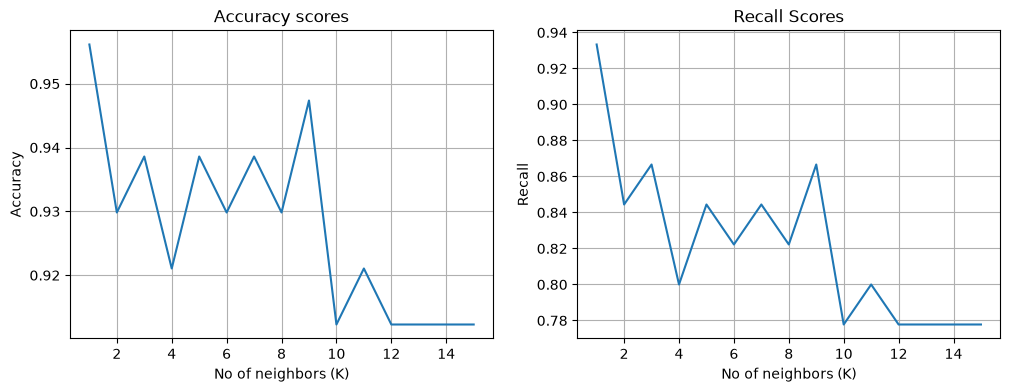

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, 16), accuracy_scores)
ax[0].set_title("Accuracy scores")
ax[0].set_xlabel("No of neighbors (K)")
ax[0].set_ylabel("Accuracy")
ax[0].grid(True)

ax[1].plot(range(1, 16), recall_scores)
ax[1].set_title("Recall Scores")
ax[1].set_xlabel("No of neighbors (K)")
ax[1].set_ylabel("Recall")
ax[1].grid(True)

plt.show()